# 线性回归

## 线性回归的基本元素


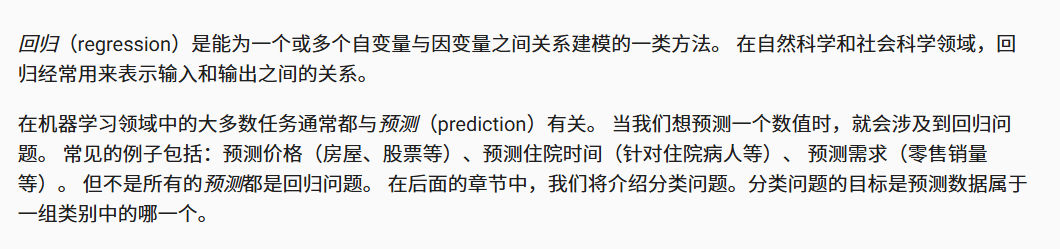

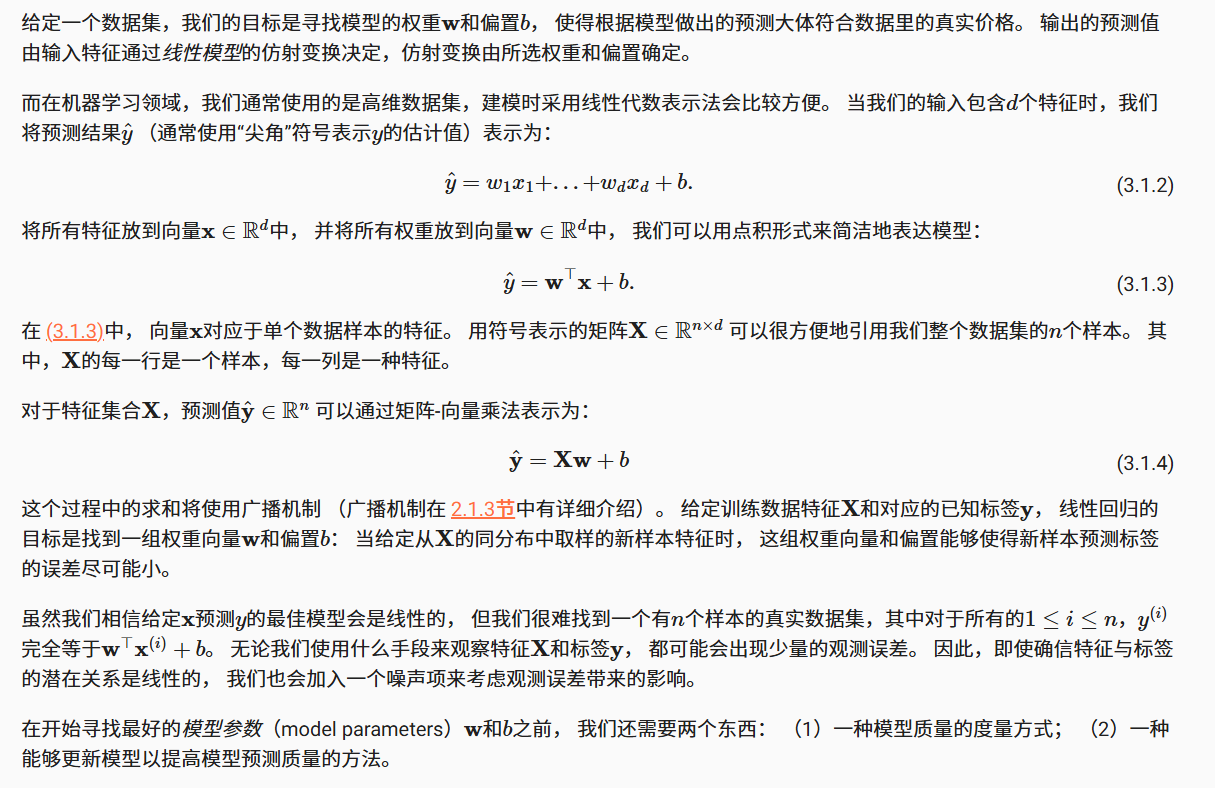

## 损失函数

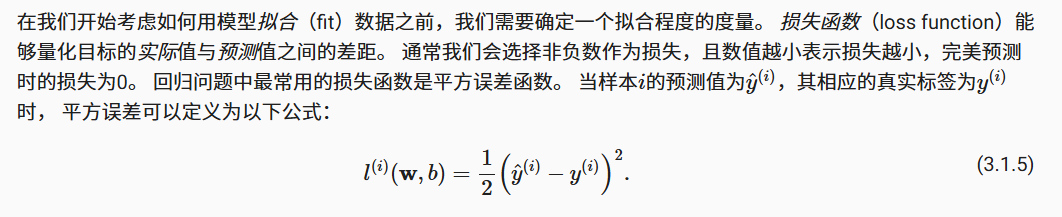

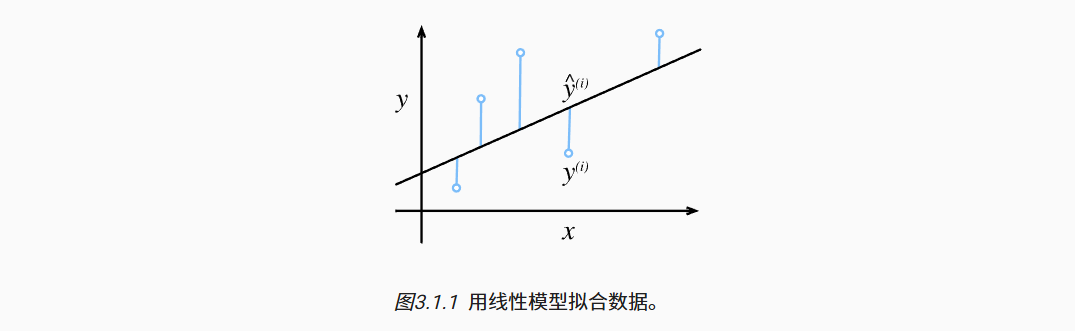

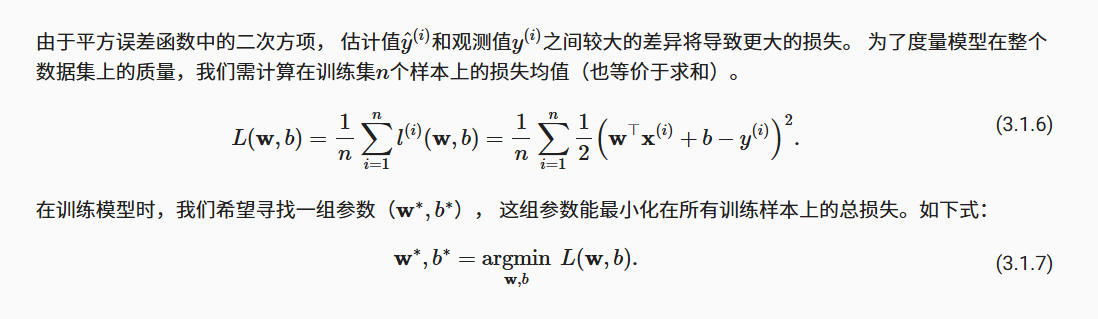

## 解析解

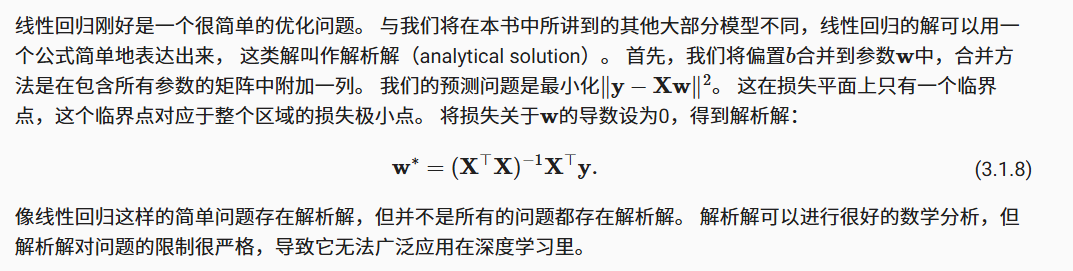

## 随机梯度下降

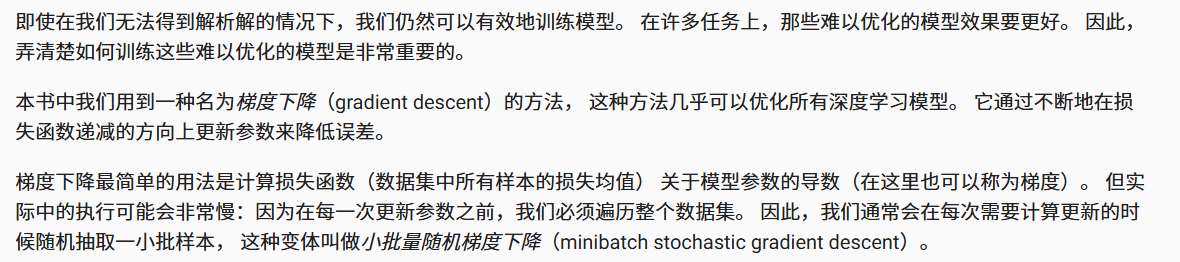

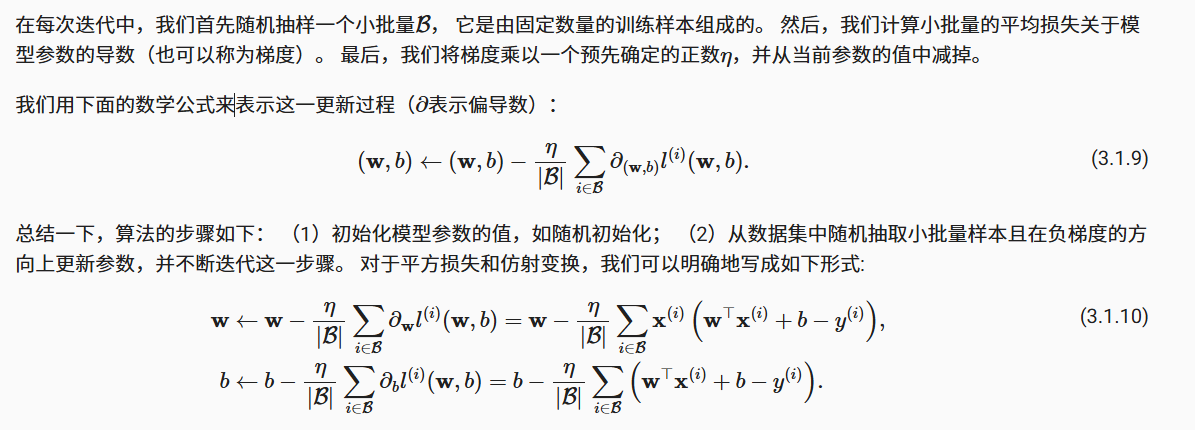

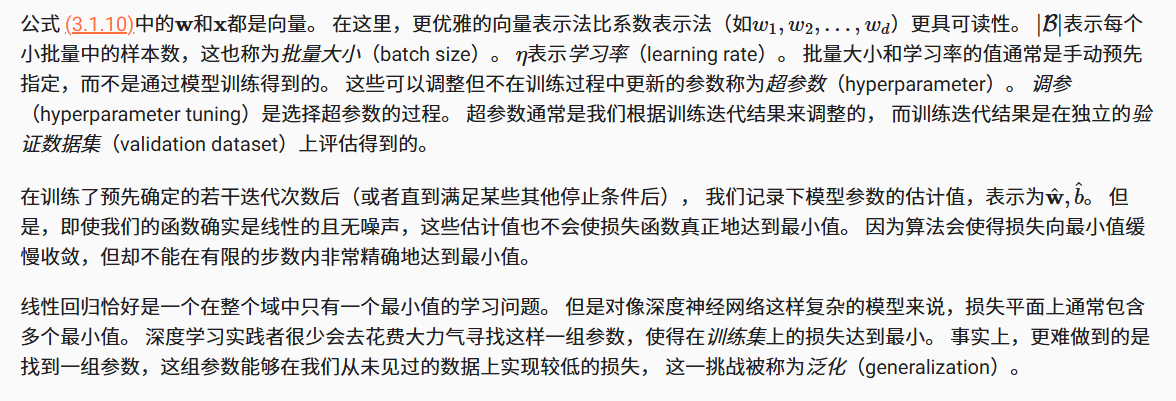

## 矢量化计算加速


实现批量梯度下降，使得模型计算更高效

In [56]:
# %matplotlib inline
import time
from os import times_result
from d2l import torch as d2l
import numpy as np
import torch

In [57]:
n = int(pow(10, 5))

In [58]:
# 初始化时间计数器类
class Timer:  #@save
    """记录多次运行时间"""
    tik = time.time()

    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """启动计时器"""
        self.tik = time.time()

    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """返回时间总和"""
        return sum(self.times)

    def cum_sum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()

In [59]:
# 测试 python-for 循环的时间消耗
c=torch.zeros(n)
time_obj=Timer()
for i in range(n):
    c[i]=a[i]+b[i]
time_obj.stop()
# 0.48096776008605957

0.4592325687408447

In [60]:
# 测试 torch-add 函数的时间消耗
a = torch.ones(n)
b = torch.ones(n)
time_obj=Timer()
d=a+b
time_obj.stop()
# 0.0007145404815673828

0.0

## 正态分布与平方计算

正态分布和线性回归之间的关系很密切。正态分布（normal distribution），也称为高斯分布（Gaussian distribution），最早由德国数学家高斯（Gauss）应用于天文学研究。简单的说，若随机变量  $x$  具有均值  $\mu$  和方差  $\sigma^2$ （标准差  $\sigma$ ），其正态分布概率密度函数如下：

 $p(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{1}{2\sigma^2}(x-\mu)^2 \right).$

In [66]:
import math
def normal(x, mu, sigma):
    """
    正态分布的密度函数
    :param x: 输入值
    :param mu: 均值
    :param sigma: 标准差
    :return: 正态分布的密度函数值
    """
    p = 1 / math.sqrt(2 * math.pi * sigma**2)
    return p * np.exp(-0.5 / sigma**2 * (x - mu)**2)

[-7.   -6.99 -6.98 ...  6.97  6.98  6.99] 1400


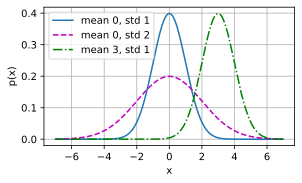

In [70]:
# 再次使用numpy进行可视化
x = np.arange(-7, 7, 0.01)
print(x,len(x))
# 均值和标准差对
params = [(0, 1), (0, 2), (3, 1)]
d2l.plot(x, [normal(x, mu, sigma) for mu, sigma in params], xlabel='x',
         ylabel='p(x)', figsize=(4.5, 2.5),
         legend=[f'mean {mu}, std {sigma}' for mu, sigma in params])

解读

就像我们所看到的，改变均值会产生沿 $x$ 轴的偏移，增加方差将会分散分布、降低其峰值。均方误差损失函数（简称均方损失）可以用于线性回归的一个原因是：我们假设了观测中包含噪声，其中噪声服从正态分布。噪声正态分布如下式:

 $y = \mathbf{w}^\top \mathbf{x} + b + \epsilon,$

其中， $\epsilon \sim \mathcal{N}(0, \sigma^2)$ 。

因此，我们现在可以写出通过给定的 $\mathbf{x}$ 观测到特定 $y$ 的**似然**（likelihood）：

 $P(y \mid \mathbf{x}) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{1}{2\sigma^2}(y - \mathbf{w}^\top \mathbf{x} - b)^2\right).$

现在，根据**极大似然估计法**，参数 $\mathbf{w}$ 和 $b$ 的最优值是使整个数据集的似然最大的值：

 $P(\mathbf{y} \mid \mathbf{X}) = \prod_{i=1}^{n} p(y^{(i)}|\mathbf{x}^{(i)}).$

根据极大似然估计法选择的估计量称为极大似然估计量。虽然使许多指数函数的乘积最大化看起来很困难，但是我们可以在不改变目标的前提下，通过最大化似然对数来简化。由于历史原因，优化通常是说最小化而不是最大化。我们可以改为最小化**负对数似然**  $-\log P(\mathbf{y} \mid \mathbf{X})$ 。由此可以得到的数学公式是:

 $-\log P(\mathbf{y} \mid \mathbf{X}) = \sum_{i=1}^{n} \frac{1}{2}\log(2\pi\sigma^2) + \frac{1}{2\sigma^2}\left(y^{(i)} - \mathbf{w}^\top \mathbf{x}^{(i)} - b\right)^2.$

现在我们只需要假设 $\sigma$ 是某个固定常数就可以忽略第一项，因为第一项不依赖于 $\mathbf{w}$ 和 $b$ 。现在第二项除了常数 $\frac{1}{\sigma^2}$ 外，其余部分和前面介绍的均方误差是一样的。幸运的是，上面式子的解并不依赖于 $\sigma$ 。因此，在高斯噪声的假设下，最小化均方误差等价于对线性模型的极大似然估计。

## 从线性回归到深度网络

神经网络图

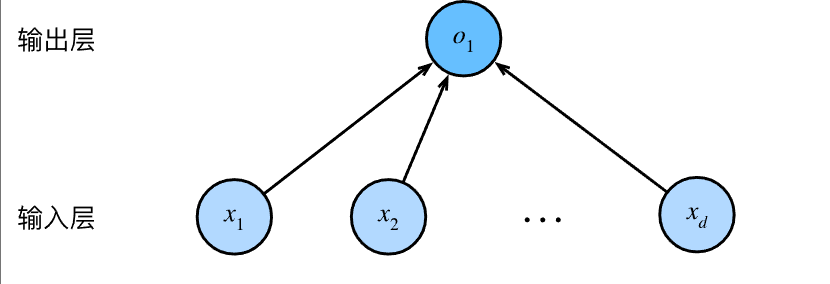

对于线性回归，每个输入和每个输出都相连在一起，我们一般选择将这种变化成为“全连接层”或称为“稠密层”。